PROJECT SUMMARY IS IN THE END - THANK YOU.


In [48]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings


warnings.filterwarnings('ignore')


In [49]:
insurance_data = pd.read_csv('../ML CODE/Data/health_insurance.csv')


In [50]:
insurance_data

,age,sex,weight,bmi,hereditary_diseases,no_of_dependents,smoker,city,bloodpressure,diabetes,regular_ex,job_title,claim
0,60.0,male,64,24.3,NoDisease,1,0,NewYork,72,0,0,Actor,13112.6
1,49.0,female,75,22.6,NoDisease,1,0,Boston,78,1,1,Engineer,9567.0
2,32.0,female,64,17.8,Epilepsy,2,1,Phildelphia,88,1,1,Academician,32734.2
3,61.0,female,53,36.4,NoDisease,1,1,Pittsburg,72,1,0,Chef,48517.6
4,19.0,female,50,20.6,NoDisease,0,0,Buffalo,82,1,0,HomeMakers,1731.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,39.0,male,49,28.3,NoDisease,1,1,Florence,54,1,0,FilmMaker,21082.2
14996,39.0,male,74,29.6,NoDisease,4,0,Miami,64,1,0,Student,7512.3
14997,20.0,male,62,33.3,NoDisease,0,0,Tampa,52,1,0,FashionDesigner,1391.5
14998,52.0,male,88,36.7,NoDisease,0,0,PanamaCity,70,1,0,Farmer,9144.6


In [51]:
# Problem Statement
# A key challenge for the insurance industry is to charge each customer an appropriate premium for the risk they represent. The ability to predict a correct claim amount has a significant impact on insurer's management decisions and financial statements. Predicting the cost of claims in an insurance company is a real-life problem that needs to be solved in a more accurate and automated way. Several factors determine the cost of claims based on health factors like BMI, age, smoker, health conditions and others. Insurance companies apply numerous techniques for analyzing and predicting health insurance costs

In [52]:
insurance_data.head(20)

# frst of  i am trying to understand this data set here over here we have predict the insurance claim price for the each pt. 
# so if am right then the by what i have noticed in this data set jst by looking at the raw data i can see that the diseases has to do somthing with the claim price.
# ppl who are smoking are also getting the higher claims
# some nans in bmi , bps are 0 , typo error in citys new york is jst york 

,age,sex,weight,bmi,hereditary_diseases,no_of_dependents,smoker,city,bloodpressure,diabetes,regular_ex,job_title,claim
0,60.0,male,64,24.3,NoDisease,1,0,NewYork,72,0,0,Actor,13112.6
1,49.0,female,75,22.6,NoDisease,1,0,Boston,78,1,1,Engineer,9567.0
2,32.0,female,64,17.8,Epilepsy,2,1,Phildelphia,88,1,1,Academician,32734.2
3,61.0,female,53,36.4,NoDisease,1,1,Pittsburg,72,1,0,Chef,48517.6
4,19.0,female,50,20.6,NoDisease,0,0,Buffalo,82,1,0,HomeMakers,1731.7
5,42.0,female,89,37.9,NoDisease,0,0,AtlanticCity,78,0,0,Dancer,6474.0
6,18.0,male,59,23.8,NoDisease,0,0,Portland,64,0,0,Singer,1705.6
7,21.0,male,52,26.8,NoDisease,0,0,Cambridge,74,1,0,Actor,1534.3
8,63.0,male,55,NaN,NoDisease,0,0,Hartford,70,1,0,Dancer,13390.6
9,40.0,female,69,29.6,NoDisease,0,0,Springfield,64,1,1,DataScientist,5910.9


In [53]:
insurance_data.tail(20)


,age,sex,weight,bmi,hereditary_diseases,no_of_dependents,smoker,city,bloodpressure,diabetes,regular_ex,job_title,claim
14980,24.0,female,53,NaN,NoDisease,3,0,Brimingham,68,0,0,Photographer,4618.1
14981,64.0,male,66,40.5,NoDisease,0,0,Charleston,56,1,0,Actor,13831.1
14982,55.0,male,76,27.5,NoDisease,0,0,Charlotte,86,0,1,Photographer,10856.0
14983,37.0,female,76,38.4,HeartDisease,0,1,Louisville,86,1,0,ITProfessional,40419.0
14984,23.0,female,52,33.4,NoDisease,0,0,Memphis,60,1,0,GovEmployee,10795.9
14985,18.0,male,50,28.5,NoDisease,0,0,Nashville,84,1,1,HomeMakers,1712.2
14986,27.0,male,87,45.9,NoDisease,2,0,NewOrleans,78,0,1,Analyst,3693.4
14987,47.0,male,94,47.5,NoDisease,1,0,Raleigh,61,1,0,Academician,8083.9
14988,52.0,female,53,24.4,NoDisease,2,0,Houston,84,0,0,Singer,19214.1
14989,44.0,male,90,38.1,NoDisease,1,0,Georgia,76,1,0,Engineer,7152.7


In [54]:

insurance_data.info()

# there are 15k rows 13 cols - and there are nulls in bmis and ages 

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  14604 non-null  float64
 1   sex                  15000 non-null  str    
 2   weight               15000 non-null  int64  
 3   bmi                  14044 non-null  float64
 4   hereditary_diseases  15000 non-null  str    
 5   no_of_dependents     15000 non-null  int64  
 6   smoker               15000 non-null  int64  
 7   city                 15000 non-null  str    
 8   bloodpressure        15000 non-null  int64  
 9   diabetes             15000 non-null  int64  
 10  regular_ex           15000 non-null  int64  
 11  job_title            15000 non-null  str    
 12  claim                15000 non-null  float64
dtypes: float64(3), int64(6), str(4)
memory usage: 1.9 MB


In [55]:
insurance_data.describe()

# i can see blood pressure as 0 whih is not possible 
# bmi of some ppl are not righrt 75% are have of 34 i thinnk it should be less than 30 and max one is having of 53



,age,weight,bmi,no_of_dependents,smoker,bloodpressure,diabetes,regular_ex,claim
count,14604.000000,15000.000000,14044.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,39.547521,64.909600,30.266413,1.129733,0.198133,68.650133,0.777000,0.224133,13401.437620
std,14.015966,13.701935,6.122950,1.228469,0.398606,19.418515,0.416272,0.417024,12148.239619
min,18.000000,34.000000,16.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1121.900000
25%,27.000000,54.000000,25.700000,0.000000,0.000000,64.000000,1.000000,0.000000,4846.900000
50%,40.000000,63.000000,29.400000,1.000000,0.000000,71.000000,1.000000,0.000000,9545.650000
75%,52.000000,76.000000,34.400000,2.000000,0.000000,80.000000,1.000000,0.000000,16519.125000
max,64.000000,95.000000,53.100000,5.000000,1.000000,122.000000,1.000000,1.000000,63770.400000


In [56]:
insurance_data[insurance_data['bmi'] == 53.100000]

,age,sex,weight,bmi,hereditary_diseases,no_of_dependents,smoker,city,bloodpressure,diabetes,regular_ex,job_title,claim
2094,18.0,male,89,53.1,NoDisease,0,0,Charleston,110,0,1,GovEmployee,1163.5
4472,18.0,male,89,53.1,NoDisease,0,0,SanDeigo,110,0,1,GovEmployee,1163.5
7498,18.0,male,89,53.1,NoDisease,0,0,Canton,110,0,1,GovEmployee,1163.5
14083,18.0,male,89,53.1,NoDisease,0,0,Lincoln,110,0,1,GovEmployee,1163.5


In [57]:
insurance_data['city'].unique()

<ArrowStringArray>
[      'NewYork',        'Boston',   'Phildelphia',     'Pittsburg',
       'Buffalo',  'AtlanticCity',      'Portland',     'Cambridge',
      'Hartford',   'Springfield',      'Syracuse',     'Baltimore',
          'York',       'Trenton',       'Warwick',  'WashingtonDC',
    'Providence',    'Harrisburg',       'Newport',      'Stamford',
     'Worcester',       'Atlanta',    'Brimingham',    'Charleston',
     'Charlotte',    'Louisville',       'Memphis',     'Nashville',
    'NewOrleans',       'Raleigh',       'Houston',       'Georgia',
      'Oklahoma',       'Orlando',         'Macon',    'Huntsville',
     'Knoxville',      'Florence',         'Miami',         'Tampa',
    'PanamaCity',     'Kingsport',      'Marshall',        'Mandan',
      'Waterloo',      'IowaCity',      'Columbia',  'Indianapolis',
    'Cincinnati',   'Bloomington',        'Salina',     'KanasCity',
     'Brookings',         'Minot',       'Chicago',       'Lincoln',
     'FallsCity

In [58]:


insurance_data['bloodpressure'] = insurance_data['bloodpressure'].replace(
    0,
    np.nan
)


In [59]:
insurance_data.isnull().sum()

age                    396
sex                      0
weight                   0
bmi                    956
hereditary_diseases      0
no_of_dependents         0
smoker                   0
city                     0
bloodpressure          756
diabetes                 0
regular_ex               0
job_title                0
claim                    0
dtype: int64

In [60]:
# visualization 

# Think like this...

# Suppose your manager comes to you and says:

# "Analyze this dataset."

# He is not saying:

# "Draw 20 histograms."

# He's asking:

# "Tell me something useful."

# The plots are just tools.

# Step 1 — Ask Yourself

# What am I trying to know?

# That's the first question.

# Question 1

# "I want to know how Age is distributed."

# Which plot answers that?

# 👉 Histogram

# Why?

# Because histograms show distributions.

# Question 2

# "I want to know if BMI has outliers."

# Which plot?

# 👉 Boxplot

# Because boxplots are designed to highlight outliers.

# Question 3

# "I want to know whether Age affects Claim."

# Which plot?

# 👉 Scatter Plot

# Because both variables are numerical.

# Question 4

# "I want to compare average claim amounts for smokers and non-smokers."

# Which plot?

# 👉 Bar Plot (or Boxplot if you're comparing distributions)

# Because one variable is categorical (smoker) and the other is numerical (claim).

# Question 5

# "I want to know how many males and females are in the dataset."

# Which plot?

# 👉 Count Plot (or Bar Plot)

# Because you're counting categories.

# 🎯 This is the framework you'll use forever.

# Don't memorize plots.

# Memorize questions.

# I want to know...	Plot
# Distribution of one numerical feature	Histogram
# Outliers in one numerical feature	Boxplot
# Relationship between two numerical features	Scatter Plot
# Number of records in each category	Count Plot
# Compare a numerical variable across categories	Boxplot or Bar Plot
# Correlation between many numerical features	Heatmap

# That's honestly 90% of beginner EDA.

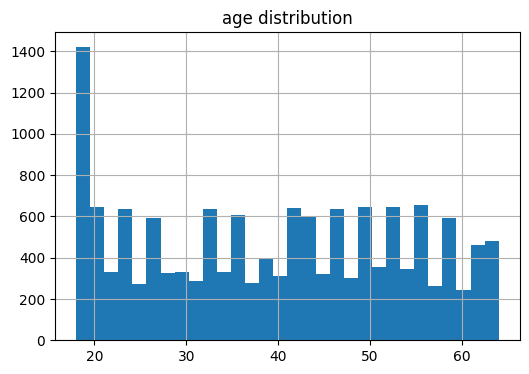

In [61]:
plt.figure(figsize=(6,4))
insurance_data['age'].hist(bins=30)
plt.title('age distribution')
plt.show()

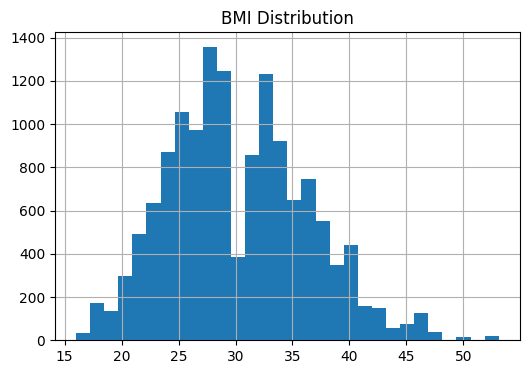

In [62]:
plt.figure(figsize=(6,4))
insurance_data['bmi'].hist(bins=30)
plt.title("BMI Distribution")
plt.show()

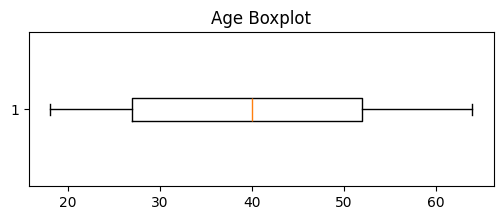

In [63]:
plt.figure(figsize=(6,2))
plt.boxplot(insurance_data['age'].dropna(), vert=False)
plt.title("Age Boxplot")
plt.show()

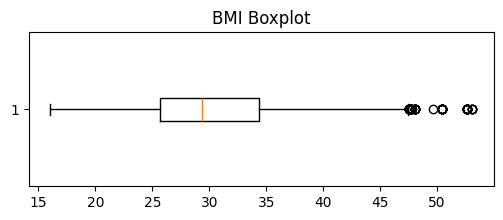

In [64]:
plt.figure(figsize=(6,2))
plt.boxplot(insurance_data['bmi'].dropna(), vert=False)
plt.title("BMI Boxplot")
plt.show()

In [65]:
# # 🎯 The Basis of Every Decision

# # This is the part I want you to remember forever.

# # We didn't choose mean or median randomly.

# # We chose them based on evidence from the EDA.

# # Feature	Distribution	Outliers	Imputation
# # Age	Approximately normal	No	Mean
# # BMI	Has outliers / not clearly normal	Yes	Median
# # Blood Pressure	Contains invalid values and may have outliers	Yes	Median

# --------------------------------------------------------------------

# ⭐ Golden Rule (Write this in your notes)

# When handling missing numerical values:

# Inspect the distribution (Histogram).
# Check for outliers (Boxplot).
# Choose the imputation method:
# Mean → Approximately normal distribution with no significant outliers.
# Median → Skewed distribution or noticeable outliers.

# Never memorize "always use mean" or "always use median."

# The data decides.

In [66]:
insurance_data['age'].fillna(
    insurance_data['age'].mean(),
    inplace=True
)

insurance_data['bmi'].fillna(
    insurance_data['bmi'].median(),
    inplace=True
)

insurance_data['bloodpressure'].fillna(
    insurance_data['bloodpressure'].median(),
    inplace=True
)

0        72.0
1        78.0
2        88.0
3        72.0
4        82.0
         ... 
14995    54.0
14996    64.0
14997    52.0
14998    70.0
14999    72.0
Name: bloodpressure, Length: 15000, dtype: float64

In [67]:
insurance_data.isnull().sum()

age                    396
sex                      0
weight                   0
bmi                    956
hereditary_diseases      0
no_of_dependents         0
smoker                   0
city                     0
bloodpressure          756
diabetes                 0
regular_ex               0
job_title                0
claim                    0
dtype: int64

In [68]:
insurance_data['age'].isnull().sum()
insurance_data['age'].dtype
insurance_data.head(30)

# insurance_data[insurance_data['age'] == 'null']


,age,sex,weight,bmi,hereditary_diseases,no_of_dependents,smoker,city,bloodpressure,diabetes,regular_ex,job_title,claim
0,60.0,male,64,24.3,NoDisease,1,0,NewYork,72.0,0,0,Actor,13112.6
1,49.0,female,75,22.6,NoDisease,1,0,Boston,78.0,1,1,Engineer,9567.0
2,32.0,female,64,17.8,Epilepsy,2,1,Phildelphia,88.0,1,1,Academician,32734.2
3,61.0,female,53,36.4,NoDisease,1,1,Pittsburg,72.0,1,0,Chef,48517.6
4,19.0,female,50,20.6,NoDisease,0,0,Buffalo,82.0,1,0,HomeMakers,1731.7
5,42.0,female,89,37.9,NoDisease,0,0,AtlanticCity,78.0,0,0,Dancer,6474.0
6,18.0,male,59,23.8,NoDisease,0,0,Portland,64.0,0,0,Singer,1705.6
7,21.0,male,52,26.8,NoDisease,0,0,Cambridge,74.0,1,0,Actor,1534.3
8,63.0,male,55,NaN,NoDisease,0,0,Hartford,70.0,1,0,Dancer,13390.6
9,40.0,female,69,29.6,NoDisease,0,0,Springfield,64.0,1,1,DataScientist,5910.9


In [69]:
insurance_data['age'] = insurance_data['age'].fillna(
    insurance_data['age'].mean()
)

insurance_data['bmi'] = insurance_data['bmi'].fillna(
    insurance_data['bmi'].median()
)

insurance_data['bloodpressure'] = insurance_data['bloodpressure'].fillna(
    insurance_data['bloodpressure'].median()
)

In [70]:
insurance_data.isnull().sum()

age                    0
sex                    0
weight                 0
bmi                    0
hereditary_diseases    0
no_of_dependents       0
smoker                 0
city                   0
bloodpressure          0
diabetes               0
regular_ex             0
job_title              0
claim                  0
dtype: int64

In [71]:
# DATA CLEANNING ACHIEVED 

In [72]:
# The computer has no mathematical meaning for these words.

# So before training, we must convert words into numbers.

# That process is called Encoding.

insurance_data.head()

,age,sex,weight,bmi,hereditary_diseases,no_of_dependents,smoker,city,bloodpressure,diabetes,regular_ex,job_title,claim
0,60.0,male,64,24.3,NoDisease,1,0,NewYork,72.0,0,0,Actor,13112.6
1,49.0,female,75,22.6,NoDisease,1,0,Boston,78.0,1,1,Engineer,9567.0
2,32.0,female,64,17.8,Epilepsy,2,1,Phildelphia,88.0,1,1,Academician,32734.2
3,61.0,female,53,36.4,NoDisease,1,1,Pittsburg,72.0,1,0,Chef,48517.6
4,19.0,female,50,20.6,NoDisease,0,0,Buffalo,82.0,1,0,HomeMakers,1731.7


In [73]:
# insurance_data[,'regular_ex'].unique()


insurance_data['smoker'].unique()
insurance_data['diabetes'].unique()
insurance_data['regular_ex'].unique()

array([0, 1])

In [74]:
# ENCODING -->

# LABEL ENCODIN && ONE HOT ENCOING 

# Job Title

# You wrote

# maybe label because claim may correlate

# 🚨 This is where I stop you.

# Correlation with Claim has nothing to do with choosing the encoding method.

# This is a huge lesson.

# The question isn't

# Does it affect the target?

# The question is

# Does the category have an order?

# For example

# Doctor

# Engineer

# Teacher

# Chef

# Does one come before another?

# No.

# So Label Encoding would create a fake order.

# Therefore

# ✅ One-Hot Encoding.

# 📋 ENCODING CHEAT SHEET
# Step 1️⃣

# Ask yourself:

# Is this column already numeric?

# Example:

# Age
# BMI
# Salary
# 0/1

# ✅ Do NOTHING.

# Step 2️⃣

# If it contains text...

# Ask:

# Does it have a natural order (hierarchy)?

# Examples:

# Small
# Medium
# Large
# High School
# Bachelor
# Master
# PhD
# Low
# Medium
# High

# ✅ Use Label (Ordinal) Encoding

# Step 3️⃣

# If there is NO order...

# Examples:

# City

# Mumbai
# Delhi
# Chennai
# Job

# Doctor
# Engineer
# Teacher
# Disease

# Diabetes
# Cancer
# Heart Disease

# ✅ Use One-Hot Encoding

# Step 4️⃣

# If there are only 2 categories

# Examples:

# Male / Female

# Yes / No

# True / False

# ✅ Convert into

# 0 / 1

In [75]:
print(insurance_data['sex'].unique())

print(insurance_data['city'].unique())

print(insurance_data['job_title'].unique())

print(insurance_data['hereditary_diseases'].unique())

<ArrowStringArray>
['male', 'female']
Length: 2, dtype: str
<ArrowStringArray>
[      'NewYork',        'Boston',   'Phildelphia',     'Pittsburg',
       'Buffalo',  'AtlanticCity',      'Portland',     'Cambridge',
      'Hartford',   'Springfield',      'Syracuse',     'Baltimore',
          'York',       'Trenton',       'Warwick',  'WashingtonDC',
    'Providence',    'Harrisburg',       'Newport',      'Stamford',
     'Worcester',       'Atlanta',    'Brimingham',    'Charleston',
     'Charlotte',    'Louisville',       'Memphis',     'Nashville',
    'NewOrleans',       'Raleigh',       'Houston',       'Georgia',
      'Oklahoma',       'Orlando',         'Macon',    'Huntsville',
     'Knoxville',      'Florence',         'Miami',         'Tampa',
    'PanamaCity',     'Kingsport',      'Marshall',        'Mandan',
      'Waterloo',      'IowaCity',      'Columbia',  'Indianapolis',
    'Cincinnati',   'Bloomington',        'Salina',     'KanasCity',
     'Brookings',       

In [76]:
# Why didn't you use Label Encoding?

# Because those categories don't have a natural order. Using Label Encoding would introduce artificial numerical relationships, so One-Hot Encoding is more appropriate despite increasing the number of columns."

In [77]:
insurance_data['sex'] = insurance_data['sex'].map({
    'male': 1,
    'female': 0
})

# Why map() over LabelEncoder?
# ✅ More readable (male → 1, female → 0 is explicit).
# ✅ No need to import another library.
# ✅ You control which value becomes 0 and which becomes 1.
# ❌ LabelEncoder decides the mapping based on alphabetical order unless you inspect it.

# For a single binary column, professionals often prefer map() because it's expl

In [78]:
insurance_data = pd.get_dummies(
    insurance_data,
    columns=['city', 'job_title', 'hereditary_diseases'],
    drop_first=True,
    dtype=int
)



In [79]:
insurance_data.info()

insurance_data.describe()
insurance_data.head()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Columns: 143 entries, age to hereditary_diseases_Obesity
dtypes: float64(4), int64(139)
memory usage: 16.4 MB


,age,sex,weight,bmi,no_of_dependents,smoker,bloodpressure,diabetes,regular_ex,claim,...,job_title_Technician,hereditary_diseases_Arthritis,hereditary_diseases_Cancer,hereditary_diseases_Diabetes,hereditary_diseases_Epilepsy,hereditary_diseases_EyeDisease,hereditary_diseases_HeartDisease,hereditary_diseases_High BP,hereditary_diseases_NoDisease,hereditary_diseases_Obesity
0,60.0,1,64,24.3,1,0,72.0,0,0,13112.6,...,0,0,0,0,0,0,0,0,1,0
1,49.0,0,75,22.6,1,0,78.0,1,1,9567.0,...,0,0,0,0,0,0,0,0,1,0
2,32.0,0,64,17.8,2,1,88.0,1,1,32734.2,...,0,0,0,0,1,0,0,0,0,0
3,61.0,0,53,36.4,1,1,72.0,1,0,48517.6,...,0,0,0,0,0,0,0,0,1,0
4,19.0,0,50,20.6,0,0,82.0,1,0,1731.7,...,0,0,0,0,0,0,0,0,1,0


In [80]:
# correlation analysis

correlation = insurance_data.corr(numeric_only=True)

correlation['claim'].sort_values(ascending=False)

claim                             1.000000
smoker                            0.773399
age                               0.298359
hereditary_diseases_Diabetes      0.215687
hereditary_diseases_EyeDisease    0.209152
                                    ...   
job_title_Labourer               -0.053533
job_title_Blogger                -0.054872
job_title_Student                -0.056643
regular_ex                       -0.060492
hereditary_diseases_NoDisease    -0.572933
Name: claim, Length: 143, dtype: float64

In [81]:
# corr()

# Calculates the correlation between every pair of numerical columns.

# Correlation ranges from:

# -1  ---------------- 0 ---------------- +1

# Negative        No Relation        Positive



# Correlation has two parts:

# 1. Direction

# Positive (+)

# ↓

# Both increase together.

# Negative (-)

# ↓

# One increases while the other decreases.

# 2. Strength

# The closer the value is to:

# +1 or -1

# the stronger the relationship.

# The closer it is to:

# 0

# the weaker the relationship.

In [82]:
# # Question:

# Should we remove low-correlation features before training?

# Professional Answer

# Not immediately.

# Correlation is only an initial indicator.

# # A feature with low individual correlation may still improve the model when combined with other features.

# My approach would be:

# Train a baseline model using all relevant features.
# Evaluate its performance.
# Perform feature selection and compare the results.
# Keep the version that generalizes better.

In [83]:
# TRAIN TREST SPLIT 

from sklearn.model_selection import train_test_split
X = insurance_data.drop(columns='claim')
y = insurance_data['claim']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [84]:
X_train.shape
X_test.shape

(3000, 142)

In [85]:
# Do more features always improve a Linear Regression model?

# Answer:

# No.

# More features can improve the model if they contain useful information about the target.

# However, adding irrelevant or noisy features can make the model more complex, increase the risk of overfitting, and sometimes reduce performance on unseen data.

In [86]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [87]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

print("R² Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R² Score: 0.7601609229798489
MAE: 3918.4605585471877
MSE: 35819999.82938721
RMSE: 5984.9811887245905


In [88]:
# # the concept of undersfitting and overfitting 
# Imagine you have 100 math questions.

# You give them to Student A.

# Student A

# He memorizes every answer.

# Question 1?

# Correct.

# Question 2?

# Correct.

# ...

# Question 100?

# Correct.

# Training Score

# 100%

# Excellent.

# Now...

# You give him

# 100 NEW questions.

# Testing Score

# 45%

# Question.

# Is he smart?

# No.

# He memorized.

# This is called
# 🚨 OVERFITTING

# The student learned

# the questions

# instead of

# the concepts.

# ------------------------------------

# Now Student B

# He studies for only

# 10 minutes.

# Training Score

# 55%

# Testing Score

# 50%

# Bad everywhere.

# This is

# 🚨 UNDERFITTING

# He never learned enough.

# -------------------------------------

# Now Student C

# He studies properly.

# Training Score

# 92%

# Testing Score

# 89%

# Excellent.

# He understands the concepts.

# He can solve

# new questions.

# This is

# ✅ GOOD FIT

In [89]:
# Cheat Sheet (Write this in your notes)
# Training	Testing	    Interpretation
# Low	    Low	❌      Underfitting
# High	    High        ✅ Good Fit
# Very      High	    Much Lower	❌ Overfitting

In [90]:
train_pred = model.predict(X_train)

print("Training R²:", r2_score(y_train, train_pred))
print("Testing R² :", r2_score(y_test, y_pred))

Training R²: 0.7688455824564241
Testing R² : 0.7601609229798489


Improving the model

In [91]:
#Feature Scalling 

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [92]:
# NOTE :
# We do NOT fit on the test data --> y.

# We only transform it.

# Why?

# Because if we fit on the test data, we'd calculate the mean and standard deviation using information that the model is supposed to have never seen.

# That would cause data leakage.

In [94]:
# now we are trainin the scalled model

model_scaled = LinearRegression()

model_scaled.fit(X_train_scaled,y_train)

y_pred_scaled = model_scaled.predict(X_test_scaled)


In [95]:
print("R²:", r2_score(y_test, y_pred_scaled))
print("MAE:", mean_absolute_error(y_test, y_pred_scaled))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_scaled)))

R²: 0.7603190830004625
MAE: 3857.443571972974
RMSE: 5983.00748855464


In [ ]:
# Did StandardScaler significantly improve the model?

# Answer

# No.

# It produced only a very tiny improvement.

# Therefore,

# The model's main limitation is not feature scaling.

In [98]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

coefficients = coefficients.sort_values(
    by='Coefficient',
    ascending=False
)

coefficients.head(15)

,Feature,Coefficient
5,smoker,20042.525264
138,hereditary_diseases_HeartDisease,3504.482097
114,job_title_Engineer,1873.056050
40,city_Indianapolis,1790.138671
124,job_title_Labourer,1676.728714
93,city_Warwick,1596.455106
127,job_title_Photographer,1579.531652
22,city_Chicago,1524.861742
7,diabetes,1333.945073
129,job_title_Politician,1323.852564


In [97]:
coefficients.tail(15)

,Feature,Coefficient
112,job_title_DefencePersonnels,-1016.507221
57,city_Miami,-1032.340903
43,city_KanasCity,-1163.601504
108,job_title_Chef,-1174.591050
81,city_SanFrancisco,-1184.015243
49,city_LosAngeles,-1254.977069
97,city_York,-1368.930552
23,city_Cincinnati,-1394.863275
58,city_Minneapolis,-1434.739798
101,job_title_Analyst,-1540.862192


In [ ]:
# 🎯 Here's the rule I want you to remember.

# Don't focus on the sign.

# Focus on the magnitude (absolute value).

# For example:

# Coefficient	Importance
# +15000	Very influential
# -12000	Very influential
# +0.001	Very little influence
# -0.002	Very little influence

In [ ]:
# This is something I want you to write in your notes.

# Correlation ≠ Coefficient

# They answer different questions.

# Correlation	Coefficient
# "Is there a relationship?"	"How much does this feature change the prediction?"
# Used during EDA	Used after training
# Before model	After model

# This confusion is very common in interviews.

# Now you know the difference.

In [ ]:
# Residual analysis --> 


# Where is my model making mistakes?
# - We already know that from MAE and RMSE.

# Is there a pattern in those mistakes?

# magine you're a cricket coach.

# A batsman gets out 20 times.

# You don't just count:

# "He got out 20 times."

# You ask:

# How?

# Maybe...

# Always against spin.
# Always on short balls.
# Always after scoring 30 runs.

# Now you have a pattern.

# Once you know the pattern...

# You know how to improve him.

# Residual analysis is exactly the same.

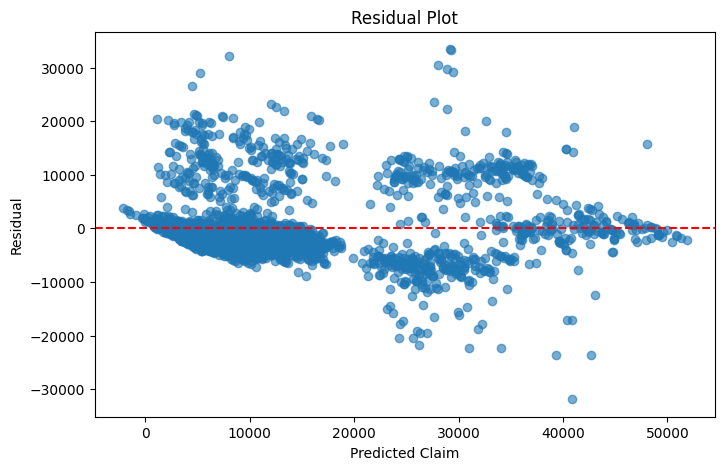

In [99]:
residuals = y_test - y_pred

plt.figure(figsize=(8,5))

plt.scatter(y_pred, residuals, alpha=0.6)

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted Claim")
plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()

In [ ]:
# Good Residual Plot - Random cloud.

# As the predictions increase, the cloud spreads more.- called Heteroscedasticity

📌 Project 2 - Insurance Claim Prediction (Multiple Linear Regression)
🎯 Objective

The goal of this project was to predict the insurance claim amount of a customer using Multiple Linear Regression.

Unlike Project #1, which contained only one feature, this dataset contained multiple numerical and categorical features, making it much closer to a real-world machine learning problem.

📊 Step 1 - Understanding the Dataset

Before writing any code, we first understood the business problem.

Dataset Overview
15,000 rows
13 original columns
Target variable: claim

During the initial inspection, I noticed:

Missing values in age and bmi
Blood pressure values equal to 0 (invalid)
Categorical features such as city, job title, and hereditary diseases
Smoking and diseases appeared likely to influence insurance claims

Instead of jumping directly into modeling, I first tried to understand the dataset like a data analyst.

📊 Step 2 - Exploratory Data Analysis (EDA)

We explored the dataset using:

shape
info()
describe()
Histograms
Box plots
Correlation heatmap

From the EDA, I learned:

Age was approximately normally distributed.
BMI contained outliers.
Smoking showed a strong positive relationship with insurance claims.
Diseases also appeared to influence claim amounts.

This step helped me build hypotheses before training the model.

🧹 Step 3 - Data Cleaning

Before training the model, we cleaned the dataset.

Tasks performed:

Replaced invalid blood pressure values.
Filled missing age values using the mean.
Filled missing BMI values using the median.
Verified that no missing values remained.

The choice of mean vs median was based on the distribution of each feature rather than using the same method everywhere.

🏷️ Step 4 - Feature Encoding

The dataset contained multiple categorical variables.

Encoding strategy:

Binary features (already 0/1) were kept unchanged.
Multi-category features were converted using One-Hot Encoding.

After encoding:

All features became numerical.
The dataset expanded to approximately 143 columns.

This demonstrated how categorical data can significantly increase dimensionality.

📈 Step 5 - Feature Relationship Analysis

Before training the model, we examined feature relationships.

We discovered:

Smoking had the strongest positive relationship with claims.
Age and diseases were also important.
Some features had weak relationships.

Instead of removing weak features immediately, we decided to train a baseline model first and evaluate it using evidence.

This was an important engineering decision.

✂️ Step 6 - Train-Test Split

The dataset was split into:

80% Training Data
20% Testing Data

We used:

train_test_split(
    test_size=0.2,
    random_state=42
)

I also learned why random_state is important for reproducibility.

🤖 Step 7 - Model Training

We trained our first Multiple Linear Regression model using:

LinearRegression()

Unlike Project #1, this model learned from more than 140 features simultaneously.

📊 Step 8 - Model Evaluation

Evaluation Metrics:

R² Score
MAE
MSE
RMSE

Results:

R² = 0.760

MAE ≈ 3857

RMSE ≈ 5983

Initially, I thought the model performed poorly because the R² was lower than Project #1.

However, I later learned that comparing different datasets is not meaningful because this dataset is much more complex and contains real-world noise.

🧠 Step 9 - Underfitting vs Overfitting

One of the biggest concepts learned during this project.

We compared:

Training R²

vs

Testing R²

Results:

Training R² = 0.7688

Testing R² = 0.7601

Since both values were very close, the model generalized well.

Conclusion:

✅ Good Fit

Not Underfitting

Not Overfitting

⚖️ Step 10 - Feature Scaling Experiment

We repeated the entire experiment using StandardScaler.

Result:

The performance improved only slightly.

Conclusion:

Feature scaling was not the bottleneck for this dataset.

This taught me an important lesson:

Not every preprocessing technique significantly improves every model.

📈 Step 11 - Coefficient Analysis

Instead of stopping after the R² score, we investigated the model.

Largest positive coefficient:

Smoker

Largest negative coefficient:

NoDisease

This helped explain why the model made certain predictions and connected the machine learning results to real business logic.

📉 Step 12 - Residual Analysis

We plotted the residuals to check the assumptions of Linear Regression.

Observations:

Residuals were mostly centered around zero.
Some spread increased for larger prediction values.
No severe overfitting was observed.

This suggested that Linear Regression captured much of the underlying pattern but still missed some complex relationships.

🎯 Final Conclusion

This project demonstrated a complete machine learning workflow.

Instead of focusing only on obtaining a high R² score, I learned how to:

Understand the business problem.
Explore the data.
Clean the dataset.
Encode categorical variables.
Train a Multiple Linear Regression model.
Evaluate performance.
Diagnose underfitting and overfitting.
Interpret coefficients.
Analyze residuals.
Understand the limitations of Linear Regression.

The final lesson was that a lower R² does not necessarily indicate a bad model.

Sometimes, it simply indicates that the chosen algorithm cannot capture all the complexity of the dataset.

📚 Key Skills Learned

✅ Exploratory Data Analysis (EDA)

✅ Missing Value Handling

✅ One-Hot Encoding

✅ Train-Test Split

✅ Multiple Linear Regression

✅ Model Evaluation

✅ Underfitting vs Overfitting

✅ Feature Scaling

✅ Coefficient Interpretation

✅ Residual Analysis

✅ Engineering Mindset